# Random Forest

In [13]:
# pip install pandas scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120

In [14]:
df = pd.read_csv('cleaned_yrbs_data.csv')

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Shape: (15694, 35)

Missing values:
Series([], dtype: int64)


,age,gender,education_level,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,...,parent_emotional_abuse,parent_physical_abuse,parent_abuse_parent,parent_uses_alcohol,parent_mental_illness,incarcerated_parent,have_friend,parent_monitoring,unfair_discipline_school,ADHD
0,15.0,Male,9th grade,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,3.0,4.0,0.0,1.0
1,16.0,Male,11th grade,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,0.0,0.0
2,17.0,Female,10th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0
3,14.0,Male,9th grade,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0
4,16.0,Male,9th grade,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,2.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,1.0,0.0


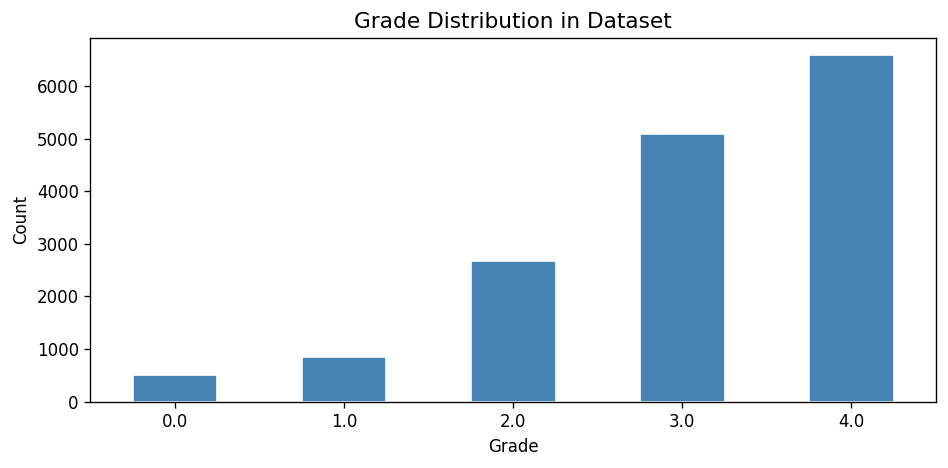

grade
0.0     506
1.0     842
2.0    2667
3.0    5094
4.0    6585
Name: count, dtype: int64


In [ ]:
#check class balance
grade_counts = df['grade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
grade_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Grade Distribution in Dataset', fontsize=13)
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(grade_counts)

In [ ]:
# Encode all string to int

df_model = df.copy()

grade_encoder = LabelEncoder()
df_model['grade'] = grade_encoder.fit_transform(df_model['grade'].astype(str))

# exclude='number' selects all non-numeric columns regardless of pandas version
for col in df_model.select_dtypes(exclude='number').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['grade'])
y = df_model['grade']

print("Features:", X.shape[1])
print("Classes :", grade_encoder.classes_)

In [17]:
# split data + keep class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size : {len(X_train):,}")
print(f"Test  size : {len(X_test):,}")

Train size : 12,555
Test  size : 3,139


In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1  # use all CPU cores
)

rf.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [19]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")
print(classification_report(
    y_test, y_pred,
    target_names=grade_encoder.classes_.astype(str)
))

Test Accuracy: 0.3820

              precision    recall  f1-score   support

         0.0       0.14      0.33      0.19       101
         1.0       0.09      0.15      0.11       168
         2.0       0.26      0.32      0.29       534
         3.0       0.38      0.21      0.27      1019
         4.0       0.55      0.57      0.56      1317

    accuracy                           0.38      3139
   macro avg       0.28      0.32      0.28      3139
weighted avg       0.41      0.38      0.38      3139



In [20]:
# evaluates model on multiple splits
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"CV Accuracy per fold : {cv_scores.round(4)}")
print(f"Mean ± Std           : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV Accuracy per fold : [0.3453 0.3609 0.3071 0.3721 0.3474]
Mean ± Std           : 0.3466 ± 0.0220


In [ ]:
# The confusion matrix shows exactly which grades the model confuses with each other
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=grade_encoder.classes_.astype(str)
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('cm_random_forest.png', bbox_inches='tight')
plt.show()

C:\Users\sitth\AppData\Local\Temp\ipykernel_5032\2234140880.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


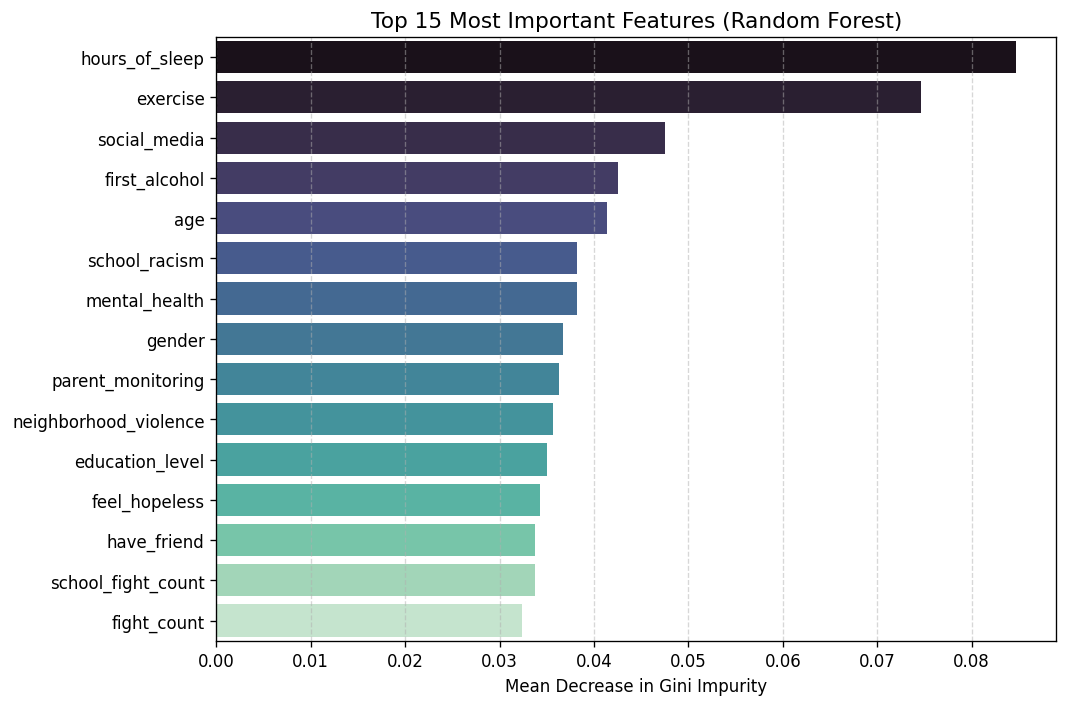

              Feature  Importance
       hours_of_sleep    0.084706
             exercise    0.074599
         social_media    0.047576
        first_alcohol    0.042599
                  age    0.041415
        school_racism    0.038239
        mental_health    0.038165
               gender    0.036753
    parent_monitoring    0.036293
neighborhood_violence    0.035664
      education_level    0.035003
        feel_hopeless    0.034273
          have_friend    0.033805
   school_fight_count    0.033760
          fight_count    0.032417


In [ ]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=importance_df.head(top_n),
    x='Importance',
    y='Feature',
    palette='mako',
    ax=ax
)
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=13)
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(importance_df.head(top_n).to_string(index=False))